# 实验二：CNN实现SVHN图像分类任务
## 1、实验内容

- 使用卷积神经网络（CNN）对SVHN（Street View House Numbers）街景门牌数字数据集进行图像分类
- 掌握图像分类问题的完整深度学习流程，包括数据预处理、模型设计、训练优化和结果分析
  
## 2、实验环境

- 编程语言: Python 3.10

- 深度学习框架: PyTorch 2.0+

- 数据处理: SciPy, NumPy

- 可视化: Matplotlib

- 数据预处理: Scikit-learn


## 3、实验数据

- SVHN（Street View House Numbers）是一个真实世界的图像数据集，来源于Google街景图像中的门牌号码。本实验使用Format 2数据集，该版本将每个数字单独裁剪成32×32像素的小图，只标注中心最主要的数字。
- 数据集结构
- - 图片规格: 32 × 32 × 3 RGB彩色图像
  - 类别数量: 10类（数字0-9）
  - 训练集规模: 73,257张图像
  - 测试集规模: 26,032张图像
  - 验证集规模: 从训练集中划分10%（7,326张）
- - 数据特点
  - 真实场景图像，包含光照变化、部分遮挡、背景干扰
  - 图像已经过裁剪和尺寸归一化
  - 标签分布相对均衡
  - 数字"0"在原始数据中标记为10，需映射为0

## 4、实验步骤与结果分析

In [1]:
# 1）环境准备
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import os
import time
warnings.filterwarnings('ignore')

seed=42
torch.manual_seed(seed)
np.random.seed(seed)

# 检查GPU是否可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# 2）加载数据与数据预处理
def load_svhn_data(train_path='train_32x32.mat', test_path='test_32x32.mat'):
    # 加载训练数据
    train_data = sio.loadmat(train_path)
    test_data = sio.loadmat(test_path)
    X_train = train_data['X']  #(32, 32, 3, 73257)
    y_train = train_data['y']
    X_test = test_data['X'] 
    y_test = test_data['y']
    
    #数据维度: (H, W, C, N) -> (N, C, H, W)
    X_train = np.transpose(X_train, (3, 2, 0, 1))
    X_test = np.transpose(X_test, (3, 2, 0, 1))
    
    y_train = y_train.flatten()
    y_test = y_test.flatten()
    y_train[y_train == 10] = 0  #将标签10转换为0
    y_test[y_test == 10] = 0
    
    X_train = X_train.astype(np.float32) / 255.0
    X_test = X_test.astype(np.float32) / 255.0
    
    return X_train, y_train, X_test, y_test

# 加载数据
print("加载数据...")
X_train, y_train, X_test, y_test = load_svhn_data()

print(f'训练集形状: {X_train.shape}')
print(f'测试集形状: {X_test.shape}')

# 划分验证集 (从训练集中分出10%作为验证集)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

print(f'训练集大小: {len(X_train)}')
print(f'验证集大小: {len(X_val)}')
print(f'测试集大小: {len(X_test)}')

# 转换为PyTorch张量
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train).long()
X_val_tensor = torch.from_numpy(X_val)
y_val_tensor = torch.from_numpy(y_val).long()
X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test).long()

# 创建基础DataLoader
batch_size = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

加载数据...
训练集形状: (73257, 3, 32, 32)
测试集形状: (26032, 3, 32, 32)
训练集大小: 65931
验证集大小: 7326
测试集大小: 26032


- 数据预处理关键步骤：
- - 维度转换：将MATLAB格式的(H,W,C,N)转换为PyTorch要求的(N,C,H,W)格式
  - 标签映射：SVHN中数字0的标签为10，需映射为0便于分类
  - 归一化：像素值从[0,255]缩放到[0,1]，加速模型收敛
  - 数据划分：从训练集中分出10%作为验证集(约7326张)，用于早停和模型选择
- 分层采样重要性：使用stratify=y_train确保每个类别在训练集和验证集中的比例一致，避免类别不平衡问题。

In [3]:
# 3）构建数据增强数据集
class SimpleAugmentation:
    def __init__(self, flip_prob=0.5, shift_range=2):
        self.flip_prob = flip_prob
        self.shift_range = shift_range
    
    def __call__(self, img):
        if np.random.random() < self.flip_prob:
            img = torch.flip(img, dims=[2])  #水平翻转

        if self.shift_range > 0:
            h_shift = np.random.randint(-self.shift_range, self.shift_range + 1)
            w_shift = np.random.randint(-self.shift_range, self.shift_range + 1)
            img = torch.roll(img, shifts=(h_shift, w_shift), dims=(1, 2))
        
        return img

class SVHNDatasetSimple(torch.utils.data.Dataset):
    def __init__(self, data, labels, augment=False):
        self.data = data
        self.labels = labels
        self.augment = augment
        self.aug = SimpleAugmentation() if augment else None
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.labels[idx]
        
        if self.augment and self.aug:
            img = self.aug(img)
        
        return img, label

train_dataset_aug = SVHNDatasetSimple(X_train_tensor, y_train_tensor, augment=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=0)

- 数据增强策略：
- - 采用水平翻转（概率50%）：模拟左右对称的街景图像，增强模型对方向变化的鲁棒性
  - 随机平移（范围±2像素）：模拟门牌号码在图像中的位置偏移，提高模型的空间不变性
  - 增强操作直接在张量上进行，避免PIL图像的转换开销
- 数据增强的意义：有效扩充训练数据多样性，防止过拟合；提高模型对真实世界变化的泛化能力

In [4]:
# 4）构建网络结构
# 基础CNN模型
class BasicCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BasicCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16x32
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8x64

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 4x4x128
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = torch.relu(out)
        return out

# 带残差连接的CNN
class ResNetCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNetCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.layer1 = self._make_layer(32, 32, 2, stride=1)
        self.layer2 = self._make_layer(32, 64, 2, stride=2)
        self.layer3 = self._make_layer(64, 128, 2, stride=2)
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)
        
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, 1))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

- BasicCNN结构特点：
- - 3个卷积块，每个块包含2个卷积层和1个最大池化层
  - 通道数逐层增加：32 → 64 → 128，提取更高级的特征
  - 使用BatchNorm加速收敛并稳定训练
  - Dropout率0.5和0.3防止过拟合
  - 全连接层将4×4×128的特征映射到10个类别
- ResNetCNN架构特点：
- - 引入残差连接（Residual Connection），解决深层网络的梯度消失问题
  - 残差块包含两个3×3卷积层，通过跳跃连接将输入直接加到输出
  - 当维度不匹配时使用1×1卷积进行投影
  - 使用全局平均池化替代全连接层，减少参数量

In [5]:
# 5）设计训练流程
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                num_epochs, device, model_name, save_dir='models'):
    
    os.makedirs(save_dir, exist_ok=True)
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    best_val_acc = 0.0
    best_epoch = 0
    
    print(f"\n{'='*80}")
    print(f"开始训练 {model_name}")
    print(f"{'='*80}")
    
    for epoch in range(num_epochs):
        # 训练
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # 验证
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # 学习率调整
        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        
        # 保存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f'{save_dir}/{model_name}_best.pth')
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] '
                  f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | '
                  f'Best Val Acc: {best_val_acc:.2f}% (Epoch {best_epoch})')
    
    print(f"\n{model_name} 训练完成！最佳验证准确率: {best_val_acc:.2f}% (Epoch {best_epoch})")
    
    # 保存训练历史
    history = {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    }
    
    return model, history


- 训练流程设计：
- - 前向传播与反向传播：标准训练循环，每个batch计算损失并更新梯度
  - 每个epoch结束后在验证集上评估，不计算梯度以节省内存
  - 使用ReduceLROnPlateau，当验证损失停滞时自动降低学习率（factor=0.5，patience=3）
  - 模型保存：仅保存验证集上表现最佳的模型权重
  - 每5个epoch输出训练进度，记录损失和准确率变化
- 优化策略：
- - 使用Adam优化器（lr=0.001，weight_decay=1e-4），自适应学习率且带L2正则化
  - 使用交叉熵损失函数，适用于多分类问题
  - Dropout和权重衰减共同防止过拟合

In [6]:
# 6）训练三个模型
num_epochs = 30
learning_rate = 0.001

all_models_results = {}

#训练 BasicCNN
basic_model = BasicCNN(num_classes=10).to(device)
basic_optimizer = optim.Adam(basic_model.parameters(), lr=learning_rate, weight_decay=1e-4)
basic_scheduler = optim.lr_scheduler.ReduceLROnPlateau(basic_optimizer, mode='min', factor=0.5, patience=3)
basic_criterion = nn.CrossEntropyLoss()

# 检查是否存在已训练的模型
if os.path.exists('models/BasicCNN_best.pth'):
    print("发现已保存的BasicCNN模型，加载中...")
    basic_model.load_state_dict(torch.load('models/BasicCNN_best.pth', map_location=device))
    print("BasicCNN模型加载成功！")
    
    # 快速评估
    _, test_acc = validate(basic_model, test_loader, basic_criterion, device)
    print(f"当前模型测试准确率: {test_acc:.2f}%")
    
    retrain = input("是否重新训练BasicCNN？(y/n): ")
    if retrain.lower() == 'y':
        print("重新初始化模型并训练...")
        basic_model = BasicCNN(num_classes=10).to(device)
        basic_optimizer = optim.Adam(basic_model.parameters(), lr=learning_rate, weight_decay=1e-4)
        basic_scheduler = optim.lr_scheduler.ReduceLROnPlateau(basic_optimizer, mode='min', factor=0.5, patience=3)
        basic_model, basic_history = train_model(basic_model, train_loader, val_loader, basic_criterion, 
                                                  basic_optimizer, basic_scheduler, num_epochs, device, 'BasicCNN')
    else:
        basic_history = None
else:
    basic_model, basic_history = train_model(basic_model, train_loader, val_loader, basic_criterion, 
                                              basic_optimizer, basic_scheduler, num_epochs, device, 'BasicCNN')

#训练 ResNetCNN
resnet_model = ResNetCNN(num_classes=10).to(device)
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate, weight_decay=1e-4)
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='min', factor=0.5, patience=3)
resnet_criterion = nn.CrossEntropyLoss()

if os.path.exists('models/ResNetCNN_best.pth'):
    print("发现已保存的ResNetCNN模型，加载中...")
    resnet_model.load_state_dict(torch.load('models/ResNetCNN_best.pth', map_location=device))
    print("ResNetCNN模型加载成功！")
    
    _, test_acc = validate(resnet_model, test_loader, resnet_criterion, device)
    print(f"当前模型测试准确率: {test_acc:.2f}%")
    
    retrain = input("是否重新训练ResNetCNN？(y/n): ")
    if retrain.lower() == 'y':
        print("重新初始化模型并训练...")
        resnet_model = ResNetCNN(num_classes=10).to(device)
        resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate, weight_decay=1e-4)
        resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='min', factor=0.5, patience=3)
        resnet_model, resnet_history = train_model(resnet_model, train_loader, val_loader, resnet_criterion, 
                                                    resnet_optimizer, resnet_scheduler, num_epochs, device, 'ResNetCNN')
    else:
        resnet_history = None
else:
    resnet_model, resnet_history = train_model(resnet_model, train_loader, val_loader, resnet_criterion, 
                                                resnet_optimizer, resnet_scheduler, num_epochs, device, 'ResNetCNN')

#训练 ResNetCNN with Data Augmentation
resnet_aug_model = ResNetCNN(num_classes=10).to(device)
resnet_aug_optimizer = optim.Adam(resnet_aug_model.parameters(), lr=learning_rate, weight_decay=1e-4)
resnet_aug_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_aug_optimizer, mode='min', factor=0.5, patience=3)
resnet_aug_criterion = nn.CrossEntropyLoss()

if os.path.exists('models/ResNetCNN_Aug_best.pth'):
    print("发现已保存的ResNetCNN_Aug模型，加载中...")
    resnet_aug_model.load_state_dict(torch.load('models/ResNetCNN_Aug_best.pth', map_location=device))
    print("ResNetCNN_Aug模型加载成功！")
    
    _, test_acc = validate(resnet_aug_model, test_loader, resnet_aug_criterion, device)
    print(f"当前模型测试准确率: {test_acc:.2f}%")
    
    retrain = input("是否重新训练ResNetCNN_Aug？(y/n): ")
    if retrain.lower() == 'y':
        print("重新初始化模型并训练...")
        resnet_aug_model = ResNetCNN(num_classes=10).to(device)
        resnet_aug_optimizer = optim.Adam(resnet_aug_model.parameters(), lr=learning_rate, weight_decay=1e-4)
        resnet_aug_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_aug_optimizer, mode='min', factor=0.5, patience=3)
        resnet_aug_model, resnet_aug_history = train_model(resnet_aug_model, train_loader_aug, val_loader, 
                                                            resnet_aug_criterion, resnet_aug_optimizer, 
                                                            resnet_aug_scheduler, num_epochs, device, 'ResNetCNN_Aug')
    else:
        resnet_aug_history = None
else:
    resnet_aug_model, resnet_aug_history = train_model(resnet_aug_model, train_loader_aug, val_loader, 
                                                        resnet_aug_criterion, resnet_aug_optimizer, 
                                                        resnet_aug_scheduler, num_epochs, device, 'ResNetCNN_Aug')



开始训练 BasicCNN
Epoch [1/30] Train Loss: 1.3888, Train Acc: 51.64% | Val Loss: 0.4284, Val Acc: 86.80% | Best Val Acc: 86.80% (Epoch 1)
Epoch [5/30] Train Loss: 0.2735, Train Acc: 92.39% | Val Loss: 0.2466, Val Acc: 92.97% | Best Val Acc: 92.97% (Epoch 5)
Epoch [10/30] Train Loss: 0.1766, Train Acc: 95.20% | Val Loss: 0.2183, Val Acc: 93.98% | Best Val Acc: 94.01% (Epoch 7)
Epoch [15/30] Train Loss: 0.0992, Train Acc: 97.30% | Val Loss: 0.2197, Val Acc: 94.65% | Best Val Acc: 94.65% (Epoch 15)
Epoch [20/30] Train Loss: 0.0585, Train Acc: 98.24% | Val Loss: 0.2632, Val Acc: 94.46% | Best Val Acc: 94.83% (Epoch 17)
Epoch [25/30] Train Loss: 0.0273, Train Acc: 99.15% | Val Loss: 0.2862, Val Acc: 94.76% | Best Val Acc: 95.07% (Epoch 23)
Epoch [30/30] Train Loss: 0.0106, Train Acc: 99.69% | Val Loss: 0.3155, Val Acc: 95.05% | Best Val Acc: 95.07% (Epoch 23)

BasicCNN 训练完成！最佳验证准确率: 95.07% (Epoch 23)

开始训练 ResNetCNN
Epoch [1/30] Train Loss: 0.6632, Train Acc: 78.98% | Val Loss: 0.4435, Val Acc

- 训练配置：
- - 统一训练30个epoch，确保充分收敛
  - 所有模型使用相同的超参数，保证对比公平性
  - 三种模型独立训练，互不干扰
  - 模型权重保存在models/目录，便于后续评估

- 训练观察：
- - BasicCNN仅用5个epoch就达到92.97%的验证准确率，说明BasicCNN能快速学习SVHN数据集的特征；但从Epoch 15开始，训练损失持续下降，但验证损失反而上升，验证准确率停滞在95%左右，表明模型开始过拟合
  - ResNetCNN具有更强的初始学习能力，Epoch 1训练准确率78.98%，远高于BasicCNN的51.64%，说明残差连接使得梯度传播更顺畅；最佳验证准确率95.25%，略高于BasicCNN的95.07%，说明相比BasicCNN，ResNetCNN在保持高训练精度的同时，验证损失增长更慢，泛化能力更强
  - 数据增强版本训练初期准确率略低，Epoch 1训练准确率为70.90%，低于ResNetCNN的78.98%，说明数据增强增加了学习难度；30个epoch后训练准确率98.06%，低于其他两个模型，说明数据增强使模型更难拟合；但是验证损失最低（0.2003），说明泛化能力最好

In [12]:
# 7）评估所有模型
print("\n" + "="*80)
print("评估所有模型在测试集上的表现")
print("="*80)

def evaluate_model(model, test_loader, criterion, device, model_name):
    test_loss, test_acc = validate(model, test_loader, criterion, device)
    print(f"{model_name:30} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")
    return test_loss, test_acc

results = {}

models_to_evaluate = [
    (basic_model, 'BasicCNN'),
    (resnet_model, 'ResNetCNN'),
    (resnet_aug_model, 'ResNetCNN + Data Augmentation')
]

for model, name in models_to_evaluate:
    model.eval()
    test_loss, test_acc = evaluate_model(model, test_loader, nn.CrossEntropyLoss(), device, name)
    results[name] = {'test_loss': test_loss, 'test_acc': test_acc}



评估所有模型在测试集上的表现
BasicCNN                       | Test Loss: 0.2605 | Test Accuracy: 95.59%
ResNetCNN                      | Test Loss: 0.1910 | Test Accuracy: 95.83%
ResNetCNN + Data Augmentation  | Test Loss: 0.1721 | Test Accuracy: 95.51%


- 结果分析：
- - ResNetCNN测试准确率达到95.83%，比验证集最佳准确率（95.25%）提升0.58%，测试损失0.1910，显著低于BasicCNN（0.2605）
  - ResNetCNN + Data Augmentation的测试损失最低（0.1721），说明模型预测更加精确；但准确率仅为95.51%，略低于BasicCNN和ResNetCNN
  - 性能瓶颈：三种模型准确率相近，说明SVHN数据集相对简单，基础模型已能取得较好效果

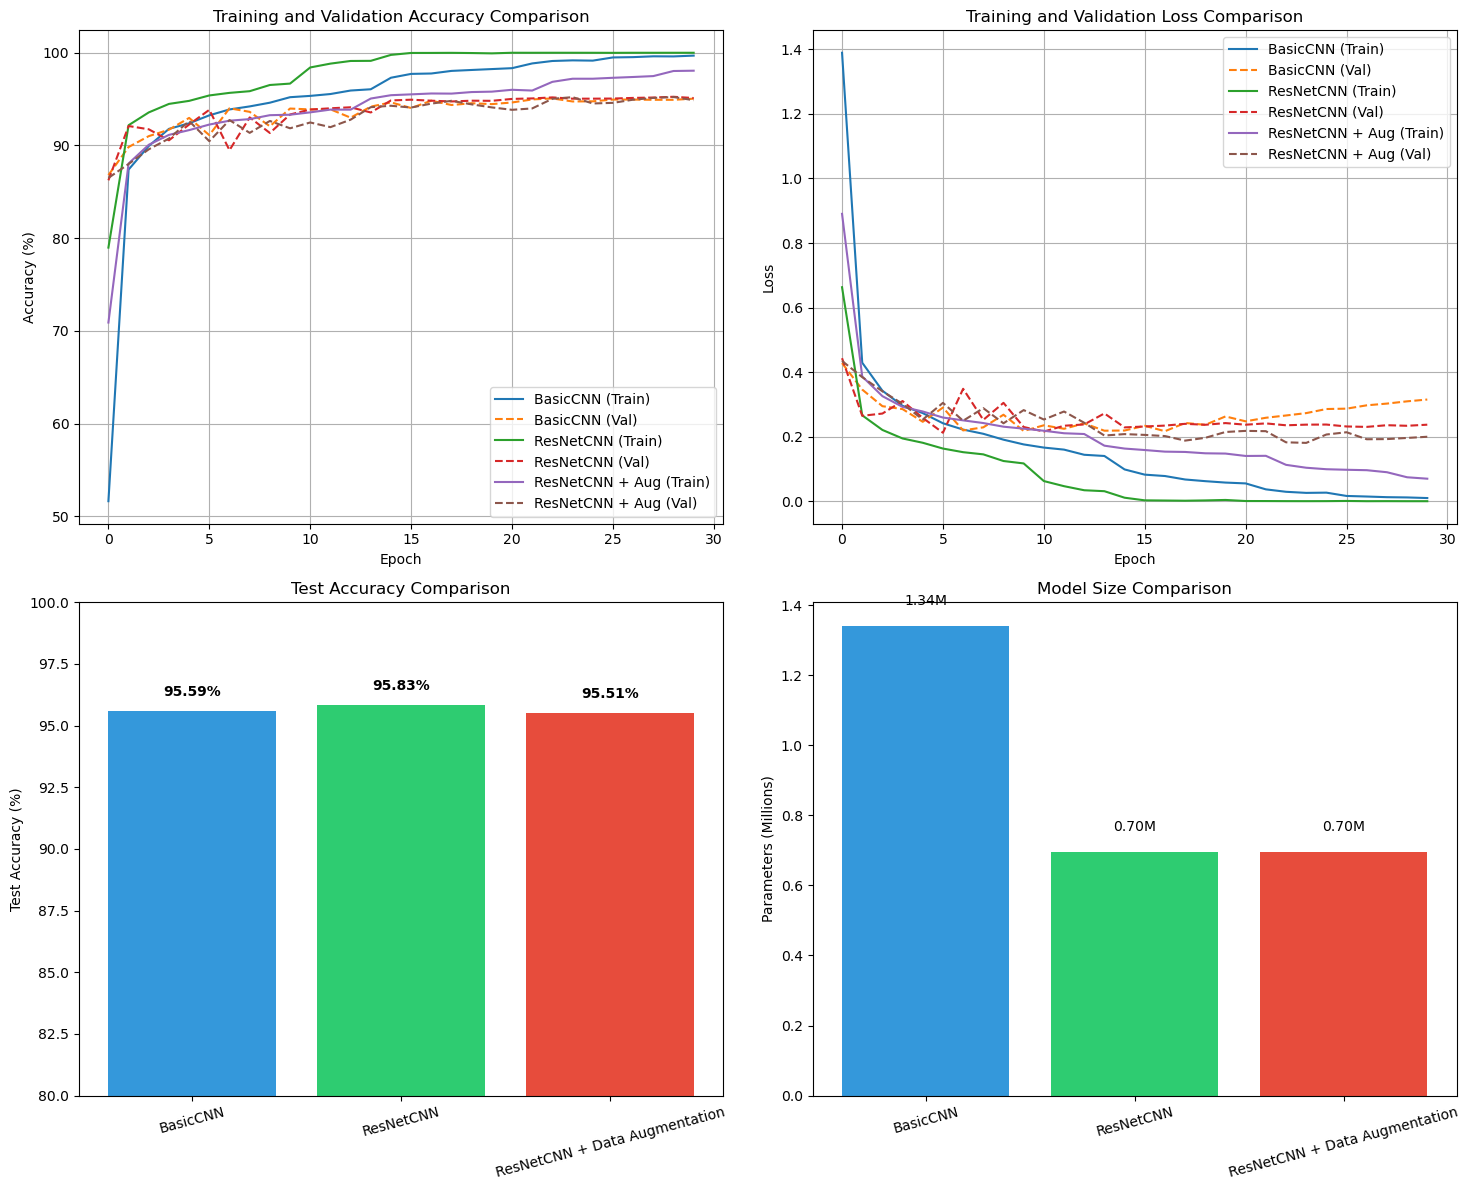

In [8]:
# 8）结果可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

histories = []
model_names = []

if basic_history is not None:
    histories.append(basic_history)
    model_names.append('BasicCNN')
if resnet_history is not None:
    histories.append(resnet_history)
    model_names.append('ResNetCNN')
if resnet_aug_history is not None:
    histories.append(resnet_aug_history)
    model_names.append('ResNetCNN + Aug')

if histories:
    # 准确率曲线
    ax1 = axes[0, 0]
    for i, history in enumerate(histories):
        ax1.plot(history['train_accs'], label=f'{model_names[i]} (Train)', linestyle='-', linewidth=1.5)
        ax1.plot(history['val_accs'], label=f'{model_names[i]} (Val)', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Training and Validation Accuracy Comparison')
    ax1.legend(loc='lower right')
    ax1.grid(True)
    
    # 损失曲线
    ax2 = axes[0, 1]
    for i, history in enumerate(histories):
        ax2.plot(history['train_losses'], label=f'{model_names[i]} (Train)', linestyle='-', linewidth=1.5)
        ax2.plot(history['val_losses'], label=f'{model_names[i]} (Val)', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Training and Validation Loss Comparison')
    ax2.legend()
    ax2.grid(True)
else:
    axes[0, 0].text(0.5, 0.5, 'No training history available', ha='center', va='center')
    axes[0, 1].text(0.5, 0.5, 'No training history available', ha='center', va='center')

# 测试准确率对比柱状图
ax3 = axes[1, 0]
model_names_list = list(results.keys())
test_accs = [results[name]['test_acc'] for name in model_names_list]
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax3.bar(model_names_list, test_accs, color=colors[:len(model_names_list)])
ax3.set_ylabel('Test Accuracy (%)')
ax3.set_title('Test Accuracy Comparison')
ax3.set_ylim([80, 100])
# 添加数值标签
for bar, acc in zip(bars, test_accs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)

# 参数量对比
ax4 = axes[1, 1]
model_params = []
for model, name in models_to_evaluate:
    params = sum(p.numel() for p in model.parameters())
    model_params.append(params / 1e6)  # 单位转换为million
bars = ax4.bar(model_names_list, model_params, color=['#3498db', '#2ecc71', '#e74c3c'])
ax4.set_ylabel('Parameters (Millions)')
ax4.set_title('Model Size Comparison')
for bar, param in zip(bars, model_params):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{param:.2f}M', ha='center', va='bottom')
ax4.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


最佳模型: ResNetCNN (测试准确率: 95.83%)

ResNetCNN 分类报告:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1744
           1       0.95      0.98      0.97      5099
           2       0.97      0.97      0.97      4149
           3       0.95      0.94      0.94      2882
           4       0.97      0.96      0.97      2523
           5       0.97      0.95      0.96      2384
           6       0.95      0.95      0.95      1977
           7       0.97      0.95      0.96      2019
           8       0.96      0.93      0.95      1660
           9       0.93      0.95      0.94      1595

    accuracy                           0.96     26032
   macro avg       0.96      0.95      0.96     26032
weighted avg       0.96      0.96      0.96     26032



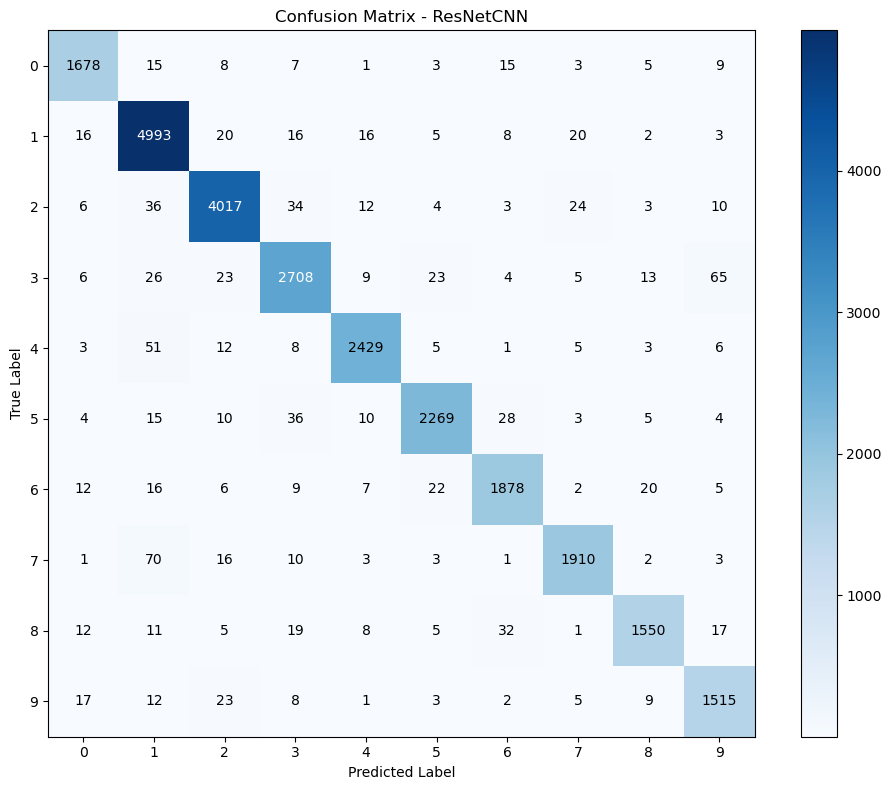

In [9]:
# 9）分类报告与混淆矩阵
# 选择测试准确率最高的模型
best_model_name = max(results, key=lambda x: results[x]['test_acc'])
best_test_acc = results[best_model_name]['test_acc']

print(f"\n最佳模型: {best_model_name} (测试准确率: {best_test_acc:.2f}%)")

# 获取最佳模型
if best_model_name == 'BasicCNN':
    best_model = basic_model
elif best_model_name == 'ResNetCNN':
    best_model = resnet_model
else:
    best_model = resnet_aug_model

# 对最佳模型进行详细评估
def get_all_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels)

y_pred, y_true = get_all_predictions(best_model, test_loader, device)

# 分类报告
print(f"\n{best_model_name} 分类报告:")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))

# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, range(10))
plt.yticks(tick_marks, range(10))

# 添加数值标注
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'confusion_matrix_{best_model_name.replace(" ", "_")}.png', dpi=150)
plt.show()


- 从分类报告可以看出：
- - 数字1、2、4表现最佳：F1分数均达到0.97，特征明显且样本数量充足
  - 数字3和9相对较弱：F1分数均为0.94，可能与数字形状相似有关
  - 样本分布存在不平衡，数字1样本最多（5,099），数字0样本最少（1,744），但模型仍保持较好性能
  - 总体性能均衡，所有类别的F1分数均在0.94以上，模型没有明显偏向
- 从混淆矩阵看，对角线元素占主导，表明分类正确率高；错误主要发生在形状相似的数字之间，符合人类视觉认知

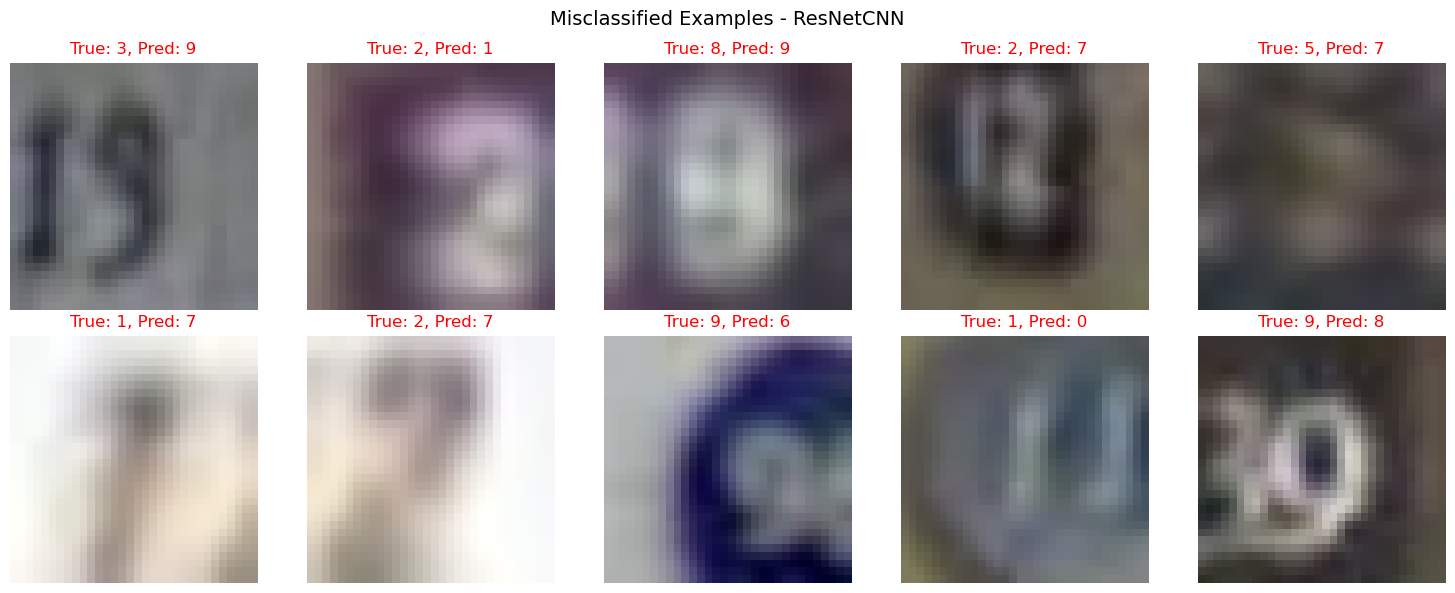


显示前10个错误分类


In [10]:
# 10）错误样本分析
def visualize_misclassified(model, dataloader, device, model_name, num_samples=10):
    model.eval()
    misclassified_images = []
    misclassified_true = []
    misclassified_pred = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            
            # 找出错误分类的样本
            incorrect = (preds != labels)
            misclassified_images.extend(inputs[incorrect].cpu())
            misclassified_true.extend(labels[incorrect].cpu())
            misclassified_pred.extend(preds[incorrect].cpu())
            
            if len(misclassified_images) >= num_samples:
                break
    
    # 可视化
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()
    
    for i in range(min(num_samples, len(misclassified_images))):
        img = misclassified_images[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f'True: {misclassified_true[i]}, Pred: {misclassified_pred[i]}', color='red')
        axes[i].axis('off')
    
    plt.suptitle(f'Misclassified Examples - {model_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'misclassified_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()
    
    print(f"\n显示前{min(num_samples, len(misclassified_images))}个错误分类")

visualize_misclassified(best_model, test_loader, device, best_model_name)

- 通过可视化错误分类的样本，可以观察到以下模式：
- - 图像质量影响：部分错误样本存在模糊、光照不均等问题；低对比度图像更容易被误分类
  - 数字相似性：比如3被误认为9，可能是由于书写风格的相似性
  - 边界情况：图像中包含边缘残影；数字位置偏移过大，超出中心区域

In [11]:
# 11）最终结果总结
print("\n" + "="*80)
print("最终结果总结")
print("="*80)

print("\n模型性能对比:")
print("-" * 60)
print(f"{'Model':<35} {'Test Accuracy':<15} {'Parameters':<15}")
print("-" * 60)

model_configs = [
    ('BasicCNN', basic_model),
    ('ResNetCNN', resnet_model),
    ('ResNetCNN + Data Augmentation', resnet_aug_model)
]

for name, model in model_configs:
    test_acc = results[name]['test_acc']
    params = sum(p.numel() for p in model.parameters()) / 1e6  # 转换为百万
    print(f"{name:<35} {test_acc:>6.2f}%{'':<8} {params:.2f}M")
print("-" * 60)

print(f"\n最佳模型: {best_model_name}")
print(f"最佳测试准确率: {best_test_acc:.2f}%")



最终结果总结

模型性能对比:
------------------------------------------------------------
Model                               Test Accuracy   Parameters     
------------------------------------------------------------
BasicCNN                             95.59%         1.34M
ResNetCNN                            95.83%         0.70M
ResNetCNN + Data Augmentation        95.51%         0.70M
------------------------------------------------------------

最佳模型: ResNetCNN
最佳测试准确率: 95.83%


- 实验总结：
- - ResNetCNN的分类效果最好，达到95.83%的测试准确率
  - 残差结构参数量少，计算效率高，有效提升了模型的泛化能力
  - 数据增强有效降低了测试损失，提高了预测置信度
  - BasicCNN虽然结构简单，仍能达到95.59%的测试准确率，验证了CNN在图像分类任务中的强大能力
- 后续改进：
- - 使用更复杂的数据增强，比如添加随机旋转、色彩抖动、高斯噪声等
  - 尝试更深层的ResNet（如ResNet-18、ResNet-34）
  - 引入注意力机制（SE-Net、CBAM）
  - 对易混淆数字对（3-8、6-8）增加训练权重，收集更多困难样本进行数据增强